<a href="https://colab.research.google.com/github/LOVELY1907/SAP_AI-ML-DL/blob/main/03_Deep_Learning/SEQ2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [ ]:
(X_train,Y_train),(X_test,Y_test) = keras.datasets.mnist.load_data()

<function matplotlib.pyplot.show(close=None, block=None)>

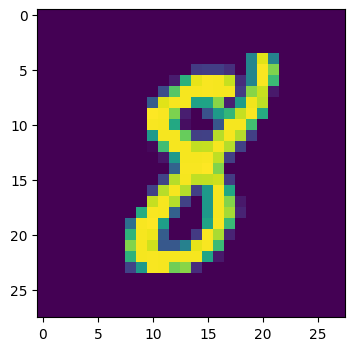

In [ ]:
#printing the data
plt.figure(figsize=(4,4))
plt.imshow(X_train[41])
plt.show

In [ ]:
#scaling
X_train = X_train / 255.0
X_test = X_test /255.0

In [ ]:
type(X_train)

numpy.ndarray

In [ ]:
#designing a CNN neural network
h_model = keras.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),

     keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#compilation
h_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
#training
h_model.fit(X_train,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9065 - loss: 0.3125
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9836 - loss: 0.0506
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 29ms/step - accuracy: 0.9903 - loss: 0.0317
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9933 - loss: 0.0205
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 33ms/step - accuracy: 0.9946 - loss: 0.0165
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 95s 40ms/step - accuracy: 0.9957 - loss: 0.0128
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9973 - loss: 0.0089
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 111s 50ms/step - accuracy: 0.9964 - loss: 0.0091
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 141s 49ms/step - accuracy: 0.9980 - loss: 0.0060
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 102s 28ms/step - accuracy: 0.9978 - loss: 0.0063


In [ ]:
#edge computing(model optimization)

#we can save this model
h_model.save('h_model.h5')

#defining the model path
model_path= '/content/h_model.h5'

In [ ]:
#defining the Converter

#getting any saved model
saved_model = keras.models.load_model(model_path)

model_converter = tf.lite.TFLiteConverter.from_keras_model(h_model)

In [ ]:
tflite_model = model_converter.convert()

Saved artifact at '/tmp/tmphza9nexn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135651893829200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135651893830352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135651893829584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135651893824592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135651893830928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135651893830544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135651893831312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135651893831120: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
with open('mnist_tflite_model.tflite','wb') as f:
  try:
    f.write(tflite_model)
  except Exception as e:
    print(e)

In [ ]:
#how to run this saved tflite model
tflite_model_path = '/content/mnist_tflite_model.tflite'

In [ ]:
#trying to build the tflite interpreter
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)

#we have to allocate the weights and biases
interpreter.allocate_tensors()

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
#Extracting input formats
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [ ]:
input_details[0]['shape']

array([ 1, 28, 28,  1], dtype=int32)

In [ ]:
# Define test_image with correct 4 dimensions (batch, height, width, channels)
test_image = X_test[0:1].astype(np.float32) # Shape: (1, 28, 28)
test_image = test_image[..., np.newaxis] # Shape: (1, 28, 28, 1)
print(f"Shape of test_image: {test_image.shape}")

Shape of test_image: (1, 28, 28, 1)


In [ ]:
#getting the weights for test image
interpreter.set_tensor(input_details[0]['index'],test_image)

In [ ]:
interpreter.invoke()

In [ ]:
image_predictions=interpreter.get_tensor(output_details[0]['index'])

In [ ]:
image_predictions

array([[2.7903003e-08, 1.9383195e-11, 1.6378547e-07, 2.7806257e-08,
        5.7240772e-09, 1.4770994e-13, 2.4537865e-15, 9.9999976e-01,
        3.4015546e-09, 1.9524332e-08]], dtype=float32)

In [ ]:
max_probability=np.argmax(image_predictions)
max_probability

np.int64(7)

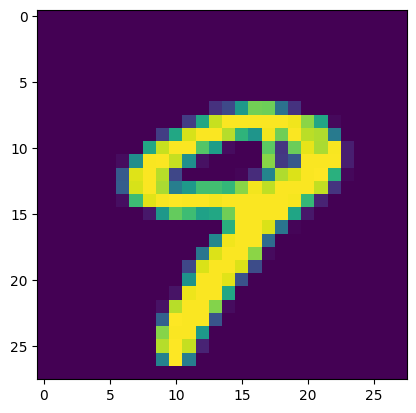

In [ ]:
plt.imshow(X_test[9])